In [31]:
from model import *
seed_vec = []
for i in range(20):

    avg_true_vector = []
    policies = []
    reward_models = []
    avg_est_vector = []

    for k in range(2,32):
        trained_policy, trained_reward_model, avg_true, avg_est = train(N=300,m=50,k=k,eta=0.05,epsilon=1e-2,grid_size=8,danger=[3,3],goal=[0,6],horizon=50,coins=[(1,1),(1,3),(6,2)],seed=i)
        avg_true_vector.append(avg_true)
        policies.append(trained_policy)
        reward_models.append(trained_reward_model)
        avg_est_vector.append(avg_est)
    
    seed_vec.append([avg_true_vector,policies,reward_models,avg_est_vector])

 
        

hi 2
hi 3
hi 4
hi 5
hi 6
hi 7
hi 8
hi 9
hi 10
hi 11
hi 12
hi 13
hi 14
hi 15
hi 16
hi 17
hi 18
hi 19
hi 20
hi 21
hi 22
hi 23
hi 24
hi 25
hi 26
hi 27
hi 28
hi 29
hi 30
hi 31
hi 2
hi 3
hi 4
hi 5
hi 6
hi 7
hi 8
hi 9
hi 10
hi 11
hi 12
hi 13
hi 14
hi 15
hi 16
hi 17
hi 18
hi 19
hi 20
hi 21
hi 22
hi 23
hi 24
hi 25
hi 26
hi 27
hi 28
hi 29
hi 30
hi 31
hi 2
hi 3
hi 4
hi 5
hi 6
hi 7
hi 8
hi 9
hi 10
hi 11
hi 12
hi 13
hi 14
hi 15
hi 16
hi 17
hi 18
hi 19
hi 20
hi 21
hi 22
hi 23
hi 24
hi 25
hi 26
hi 27
hi 28
hi 29
hi 30
hi 31
hi 2
hi 3
hi 4
hi 5
hi 6
hi 7
hi 8
hi 9
hi 10
hi 11
hi 12
hi 13
hi 14
hi 15
hi 16
hi 17
hi 18
hi 19
hi 20
hi 21
hi 22
hi 23
hi 24
hi 25
hi 26
hi 27
hi 28
hi 29
hi 30
hi 31
hi 2
hi 3
hi 4
hi 5
hi 6
hi 7
hi 8
hi 9
hi 10
hi 11
hi 12
hi 13
hi 14
hi 15
hi 16
hi 17
hi 18
hi 19
hi 20
hi 21
hi 22
hi 23
hi 24
hi 25
hi 26
hi 27
hi 28
hi 29
hi 30
hi 31
hi 2
hi 3
hi 4
hi 5
hi 6
hi 7
hi 8
hi 9
hi 10
hi 11
hi 12
hi 13
hi 14
hi 15
hi 16
hi 17
hi 18
hi 19
hi 20
hi 21
hi 22
hi 23
hi 24
hi 25
hi 2

In [32]:
import numpy as np

# np.save("avg_true_vector.npy", np.array(avg_true_vector, dtype=object))
# np.save("avg_est_vector.npy", np.array(avg_est_vector, dtype=object))
# np.save("policies.npy", np.array(policies, dtype=object))
# np.save("reward_models.npy", np.array(reward_models, dtype=object))
np.save("seed_vec.npy", np.array(reward_models, dtype=object))

In [12]:
def run_sim(trained_policy,k,n_sim=50):
    pi = trained_policy
    average_return = 0
    for t in range(n_sim):
        done = 0
        env = GridWorld(k,7,size=8, danger=(3,3), goal=(0,6), coins=[(1,1),(1,3),(6,2)], horizon=50) ##set value of k here
        s = env.reset() 
        c = set([(1,1),(1,3),(6,2)])
        while not done:
            a, _ = policy.act(s)
            s, done = env.step(a)
        y, _ = env.get_feedback_and_features()
        average_return+=y
    return average_return/n_sim
        

In [41]:
a,b,c,d = seed_vec[0]
average_return_vec = []
for i in range(len(b)):
    policy = b[i]
    average_return_vec.append(run_sim(policy,i+2,n_sim=500))

In [42]:
average_return_vec = [
    (float(val)/(i+2) * 100.0, i+2)
    for i, val in enumerate(average_return_vec)
]

average_return_vec.sort(key=lambda x: x[0],reverse=True)
average_return_vec

[(87.6, 23),
 (87.45384615384614, 26),
 (85.37000000000002, 20),
 (79.26666666666668, 9),
 (56.48571428571428, 28),
 (56.37241379310345, 29),
 (56.01666666666667, 24),
 (55.858064516129026, 31),
 (55.38095238095239, 21),
 (54.84444444444444, 27),
 (54.29090909090909, 22),
 (53.2, 16),
 (52.41818181818182, 11),
 (52.41428571428571, 14),
 (52.15384615384615, 13),
 (51.13999999999999, 10),
 (51.1, 18),
 (49.96470588235294, 17),
 (46.51428571428571, 7),
 (41.0, 4),
 (34.35333333333333, 30),
 (25.974999999999998, 8),
 (25.464, 25),
 (24.705263157894734, 19),
 (7.066666666666667, 3),
 (5.666666666666667, 6),
 (5.24, 5),
 (5.166666666666667, 12),
 (4.666666666666666, 15),
 (4.1000000000000005, 2)]

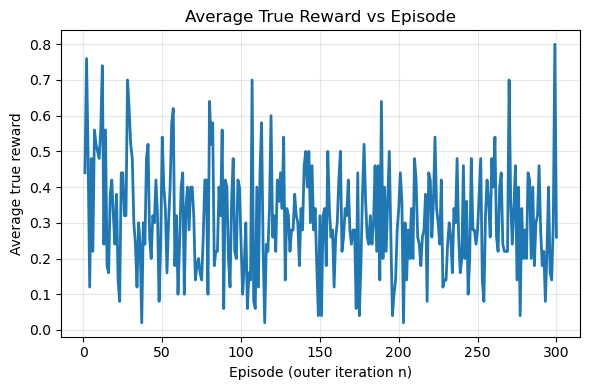

In [30]:
import matplotlib.pyplot as plt

episodes = np.arange(1, len(avg_true_vector[13]) + 1)

plt.figure(figsize=(6,4))
plt.plot(episodes, avg_true_vector[4], linewidth=2)  
plt.xlabel("Episode (outer iteration n)")
plt.ylabel("Average true reward")
plt.title("Average True Reward vs Episode")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [43]:
for seed in range(20):
    a,b,c,d = seed_vec[seed]
    average_return_vec = []
    for i in range(len(b)):
        policy = b[i]
        average_return_vec.append(run_sim(policy,i+2,n_sim=500))
    average_return_vec = [
    (float(val)/(i+2) * 100.0, i+2)
    for i, val in enumerate(average_return_vec)
    ]

    average_return_vec.sort(key=lambda x: x[0],reverse=True)
    print(average_return_vec[0])

(88.4, 26)
(86.25263157894739, 19)
(88.94666666666667, 30)
(87.11333333333333, 30)
(85.98518518518519, 27)
(87.66666666666667, 27)
(87.33571428571429, 28)
(86.24516129032259, 31)
(87.92380952380951, 21)
(88.27407407407406, 27)
(86.48421052631579, 19)
(87.70714285714286, 28)
(88.46000000000001, 30)
(87.64615384615385, 26)
(88.8, 29)
(85.05714285714285, 21)
(86.5913043478261, 23)
(86.384, 25)
(87.248, 25)
(88.39047619047619, 21)
